In [45]:
from catboost import CatBoostRegressor, Pool
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [49]:
train_df = pd.read_csv("Train.csv")
test_df = pd.read_csv("Test.csv")

df2011 = train_df[train_df["date"].str.split('-').str[0].astype(int) == 2011].copy()
df2011["price_qm"] = df2011["price"] / df2011["area"]

street_stats = (
    df2011.groupby("street_id")["price_qm"].agg
    (
        street_mean_qm="mean",
        street_median_qm="median",
        street_min_qm="min",
        street_max_qm="max",
    )
    .reset_index()
)
global_stats = {
    "mean": df2011["price_qm"].mean(),
    "median": df2011["price_qm"].median(),
    "min": df2011["price_qm"].min(),
    "max": df2011["price_qm"].max(),
}

max_metro_dist = train_df["metro_dist"].max()

In [50]:
def prep(df, max_metro_dist):
    df["is_first_floor"] = np.where(df["floor"] == 1, 1, 0)
    df["month"] = df["date"].str.split('-').str[1].astype(int)
    df["year"] = df["date"].str.split('-').str[0].astype(int)
    df["time"] = (df["year"] - 2011) * 12 + df["month"]
    df.drop(columns="date", inplace=True)

    df["build_tech"] = df["build_tech"].fillna(-1).astype(str)
    df["metro_dist"] = df["metro_dist"].fillna(max_metro_dist)
    df["metro_dist_log"] = np.log1p(df["metro_dist"])
    df["g_lift"] = df["g_lift"].fillna(0).astype(int)
    df["is_no_photos"] = np.where(df["n_photos"] == 0, 1, 0)
    df['area_per_room'] = df['area'] / df['rooms']
    df["rooms_per_area"] = df["rooms"] / df["area"]
    street_counts = df["street_id"].value_counts()
    df["street_freq"] = df["street_id"].map(street_counts)
    df["area_x_rooms"] = df["area"] * df["rooms"]
    df["metro_log_x_area"] = df["metro_dist_log"] * df["area"]
    df["floor_x_area"] = df["floor"] * df["area"]
    kw_cols = [col for col in df.columns if col.startswith("kw")]
    df["kw_total_count"] = df[kw_cols].sum(axis=1)
    return df

In [51]:
train_prep_basic = prep(train_df, max_metro_dist)
test_prep_basic = prep(test_df, max_metro_dist)

In [52]:
folds_config = [
    {"train": list(range(1, 13)), "valid": [13, 14, 15]}
    ,{"train": list(range(1, 16)), "valid": [22, 23]}
    ,{"train": list(range(1, 24)), "valid": [24]}
]

cat_features = ["street_id", "build_tech"]

In [53]:
def get_fold_data_perfect(train_prep_basic, fold, target_format="numpy"):
    
    train_mask = train_prep_basic["time"].isin(fold["train"])
    valid_mask = train_prep_basic["time"].isin(fold["valid"])

    train_fold = train_prep_basic[train_mask].copy()
    val_fold = train_prep_basic[valid_mask].copy()

    base_year_fold = train_fold["year"].min()
    df_base = train_fold[train_fold["year"] == base_year_fold].copy()
    df_base["price_qm"] = df_base["price"] / df_base["area"]

    street_stats_fold = (
        df_base.groupby("street_id")["price_qm"]
        .agg(
            street_mean_qm="mean",
            street_median_qm="median",
            street_min_qm="min",
            street_max_qm="max",
        )
        .reset_index()
    )

    street_stats_fold["street_id"] = street_stats_fold["street_id"].astype(str)
    train_fold["street_id"] = train_fold["street_id"].astype(str)
    val_fold["street_id"] = val_fold["street_id"].astype(str)

    global_stats_fold = {
        "mean": df_base["price_qm"].mean(),
        "median": df_base["price_qm"].median(),
        "min": df_base["price_qm"].min(),
        "max": df_base["price_qm"].max(),
    }

    train_fold = train_fold.merge(street_stats_fold, on="street_id", how="left")
    val_fold = val_fold.merge(street_stats_fold, on="street_id", how="left")

    for stat in ["mean", "median", "min", "max"]:
        train_fold[f"street_{stat}_qm"] = train_fold[f"street_{stat}_qm"].fillna(global_stats_fold[stat])
        val_fold[f"street_{stat}_qm"] = val_fold[f"street_{stat}_qm"].fillna(global_stats_fold[stat])


    X_train = train_fold.drop(columns=["price", "id", "year", "metro_dist"], errors="ignore")
    y_train_log = np.log1p(train_fold["price"])

    X_val = val_fold.drop(columns=["price", "id", "year", "metro_dist"], errors="ignore")
    y_val_real = val_fold["price"].values

    if target_format == "category":
        for col in cat_features:
            X_train[col] = X_train[col].astype("category")
            X_val[col] = X_val[col].astype("category")

    return X_train, y_train_log, X_val, y_val_real


In [54]:
N_TRIALS = 25
def cb_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.07),
        "depth": trial.suggest_int("depth", 4, 7),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.001, 6.0),
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }
    maes = []
    for fold in folds_config:
        X_tr, y_tr, X_va, y_va = get_fold_data_perfect(
            train_prep_basic, fold, target_format="numpy"
        )
        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr, y_tr, cat_features=cat_features),
            eval_set=Pool(X_va, np.log1p(y_va), cat_features=cat_features),
            early_stopping_rounds=30,
            verbose=0,
        )
        preds = np.expm1(model.predict(Pool(X_va, cat_features=cat_features)))
        maes.append(mean_absolute_error(y_va, preds))
    return np.mean(maes)


cb_study = optuna.create_study(direction="minimize")
cb_study.optimize(cb_objective, n_trials=N_TRIALS)
best_cb_params = {**cb_study.best_params, "random_seed": 42, "verbose": 0}

[I 2026-05-20 22:47:01,116] A new study created in memory with name: no-name-6cffdc21-6853-4fe0-9491-d66c12331f90
[I 2026-05-20 22:53:30,313] Trial 0 finished with value: 971283.5991481381 and parameters: {'iterations': 1108, 'learning_rate': 0.029084355214459373, 'depth': 4, 'l2_leaf_reg': 1.0256483225022783}. Best is trial 0 with value: 971283.5991481381.
[I 2026-05-20 22:58:30,179] Trial 1 finished with value: 971293.8175182893 and parameters: {'iterations': 720, 'learning_rate': 0.0609107277064347, 'depth': 6, 'l2_leaf_reg': 1.829073041053593}. Best is trial 0 with value: 971283.5991481381.
[I 2026-05-20 23:03:39,115] Trial 2 finished with value: 958856.6046858751 and parameters: {'iterations': 1986, 'learning_rate': 0.06386856103572523, 'depth': 5, 'l2_leaf_reg': 1.7268241732463019}. Best is trial 2 with value: 958856.6046858751.
[I 2026-05-20 23:08:10,029] Trial 3 finished with value: 960126.759951327 and parameters: {'iterations': 1438, 'learning_rate': 0.06662381121401374, 'dep

In [ ]:
def lgb_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 7)
    max_leaves = min(80, 2**max_depth)
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.07),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 7, max_leaves),
        "random_state": 42,
        "verbose": -1,
    }
    maes = []
    for fold in folds_config:
        X_tr, y_tr, X_va, y_va = get_fold_data_perfect(
            train_prep_basic, fold, target_format="category"
        )
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, np.log1p(y_va))],
            callbacks=[lgb.early_stopping(30, verbose=False)],
        )
        preds = np.expm1(model.predict(X_va))
        maes.append(mean_absolute_error(y_va, preds))
    return np.mean(maes)


lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS)
best_lgb_params = {**lgb_study.best_params, "random_state": 42, "verbose": -1}

In [ ]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.07),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "enable_categorical": True,
        "tree_method": "hist",
        "random_state": 42,
    }
    maes = []
    for fold in folds_config:
        X_tr, y_tr, X_va, y_va = get_fold_data_perfect(
            train_prep_basic, fold, target_format="category"
        )
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, np.log1p(y_va))],
            early_stopping_rounds=30,
            verbose=False,
        )
        preds = np.expm1(model.predict(X_va))
        maes.append(mean_absolute_error(y_va, preds))
    return np.mean(maes)


xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS)
best_xgb_params = {
    **xgb_study.best_params,
    "enable_categorical": True,
    "tree_method": "hist",
    "random_state": 42,
}

In [ ]:
split_month = 21
final_fold_config = {
    "train": list(range(1, 22)),
    "valid": list(range(21, 25)),
}

X_block_A, y_block_A_log, X_block_B, y_block_B_real = get_fold_data_perfect(train_prep_basic, final_fold_config, target_format="numpy")

train_mask_A = train_prep_basic["time"] <= 21
df_base_final = train_prep_basic[train_mask_A & (train_prep_basic["year"] == 2011)].copy()
df_base_final["price_qm"] = df_base_final["price"] / df_base_final["area"]

street_stats_final = (
    df_base_final.groupby("street_id")["price_qm"]
    .agg(
        street_mean_qm="mean",
        street_median_qm="median",
        street_min_qm="min",
        street_max_qm="max",
    )
    .reset_index()
)
street_stats_final["street_id"] = street_stats_final["street_id"].astype(str)
global_stats_final = {
    "mean": df_base_final["price_qm"].mean(),
    "median": df_base_final["price_qm"].median(),
    "min": df_base_final["price_qm"].min(),
    "max": df_base_final["price_qm"].max(),
}

test_prep_final = test_prep_basic.merge(street_stats_final, on="street_id", how="left")

for stat in ["mean", "median", "min", "max"]:
    test_prep_final[f"street_{stat}_qm"] = test_prep_final[
        f"street_{stat}_qm"
    ].fillna(global_stats_final[stat])

df["street_mean_qm"] = df["street_mean_qm"].fillna(global_stats_final["mean"])
df["street_median_qm"] = df["street_median_qm"].fillna(global_stats_final["median"])
df["street_min_qm"] = df["street_min_qm"].fillna(global_stats_final["min"])
df["street_max_qm"] = df["street_max_qm"].fillna(global_stats_final["max"])

X_test = test_prep_final.drop(columns=["id", "price", "year"], errors="ignore")

X_block_A_lgb, X_block_B_lgb, X_test_lgb = (
    X_block_A.copy(),
    X_block_B.copy(),
    X_test.copy(),
)
for col in cat_features:
    X_block_A_lgb[col] = X_block_A_lgb[col].astype("category")
    X_block_B_lgb[col] = X_block_B_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

final_cb = CatBoostRegressor(**best_cb_params).fit(Pool(X_block_A, y_block_A_log, cat_features=cat_features))
final_lgb = lgb.LGBMRegressor(**best_lgb_params).fit(X_block_A_lgb, y_block_A_log)
final_xgb = xgb.XGBRegressor(**best_xgb_params).fit(X_block_A_lgb, y_block_A_log))

In [ ]:
meta_X_val = pd.DataFrame(
    {
        "cb": final_cb.predict(Pool(X_block_B, cat_features=cat_features))
        ,"lgb": final_lgb.predict(X_block_B_lgb)
        ,"xgb": final_xgb.predict(X_block_B_lgb)
    }
)
meta_X_val["time"] = X_block_B["time"].reset_index(drop=True)

meta_X_test = pd.DataFrame(
    {
        "cb": final_cb.predict(Pool(X_test, cat_features=cat_features))
        ,"lgb": final_lgb.predict(X_test_lgb)
        ,"xgb": final_xgb.predict(X_test_lgb)
    }
)
meta_X_test["time"] = X_test["time"].reset_index(drop=True)

In [ ]:
def ridge_objective(trial):
    alpha = trial.suggest_float("alpha", 0.01, 100, log=True)
    kf_meta = KFold(n_splits=3, shuffle=True, random_state=42)
    meta_maes = []

    for m_train_idx, m_val_idx in kf_meta.split(meta_X_val):
        mx_tr, mx_va = meta_X_val.iloc[m_train_idx], meta_X_val.iloc[m_val_idx]
        my_tr_real, my_va_real = (
            y_block_B_real[m_train_idx],
            y_block_B_real[m_val_idx],
        )

        r_model = Ridge(alpha=alpha)
        r_model.fit(mx_tr, np.log1p(my_tr_real))

        preds_log = r_model.predict(mx_va)
        preds_real = np.expm1(preds_log)

        meta_maes.append(mean_absolute_error(my_va_real, preds_real))

    return np.mean(meta_maes)


ridge_study = optuna.create_study(direction="minimize")
ridge_study.optimize(ridge_objective, n_trials=50)
best_alpha = ridge_study.best_params["alpha"]

meta_model = Ridge(alpha=best_alpha)
meta_model.fit(meta_X_val, np.log1p(y_block_B_real))

In [ ]:

val_preds_log = meta_model.predict(meta_X_val)
val_preds_real = np.expm1(val_preds_log)

final_mape = mean_absolute_percentage_error(y_block_B_real, val_preds_real)
final_mae = mean_absolute_error(y_block_B_real, val_preds_real)
print(f"mape {final_mape}")
print(f"mae {final_mae}")

for col, coef in zip(meta_X_val.columns, meta_model.coef_):
    print(f"{col}: {coef}")

test_preds_log = meta_model.predict(meta_X_test)
test_preds_real = np.expm1(test_preds_log)

submission = pd.DataFrame({"id": test_df["id"], "price": test_preds_real})
submission.to_csv("submission.csv", index=False)

In [ ]:
train_prep["time"].value_counts(dropna=False)

In [ ]:
train_df["date"].value_counts(dropna=False)

In [23]:
testdf = pd.read_csv("Test.csv")

In [97]:
df["balcon"].isna().sum()

np.int64(0)

Text(0.5, 1.0, 'Средняя цена квартиры по количеству балконов')

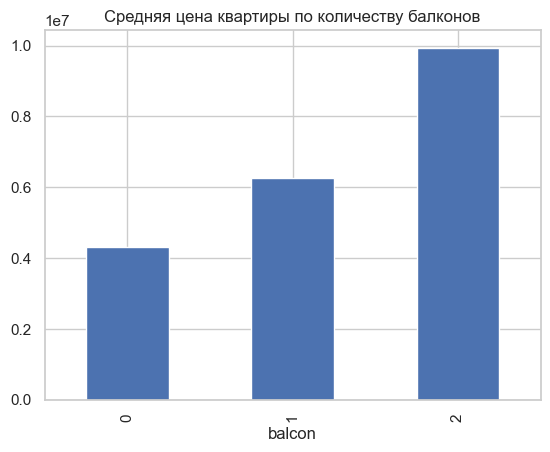

In [102]:
df.groupby("balcon")["price"].mean().plot(kind="bar")
plt.title("Средняя цена квартиры по количеству балконов")

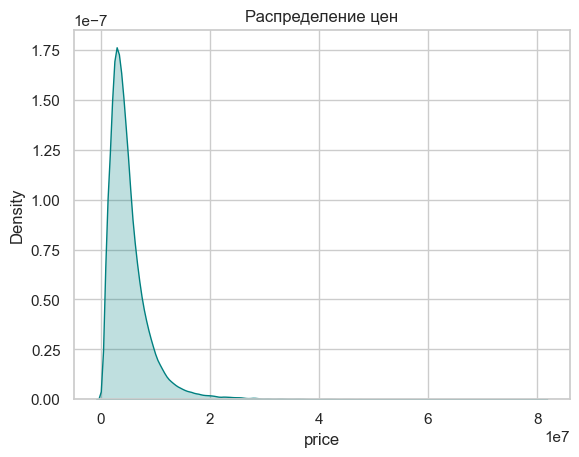

In [106]:
sns.kdeplot(data=df, x="price", fill=True)
plt.title("Распределение цен")
plt.show()

Text(0.5, 1.0, 'Средняя цена квартиры по наличию лифта')

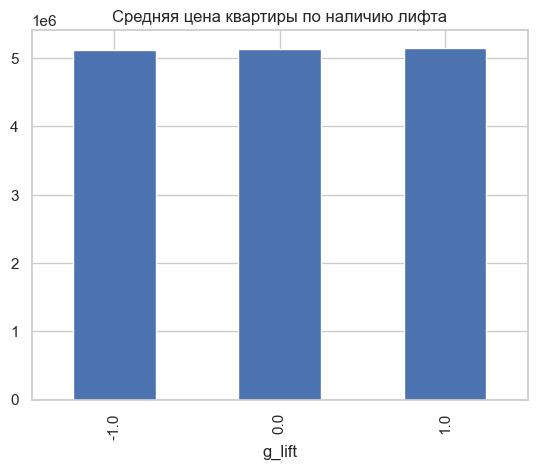

In [119]:
df.groupby("g_lift")["price"].mean().plot(kind="bar")
plt.title("Средняя цена квартиры по наличию лифта")

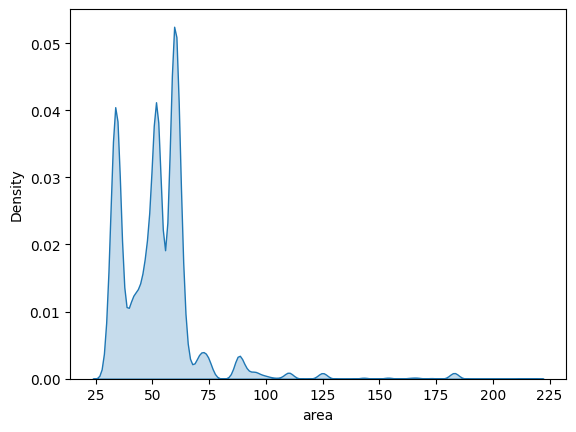

In [12]:
sns.kdeplot(data=df, x="area", fill=True)
plt.show()

In [1]:
import sys
!{sys.executable} -m pip install lightgbm optuna xgboost

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 4.2 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\b4nny\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
